## Plotting and Evaluating Microlensing Systems of Various Masses and Distances

### Observables Used to Constrain Lens Mass
To constrain $M_L$, I plotted various combinations of observables:
- $\pi_E$ and $\theta_E$
- $\pi_E$ and $F_L$
- $\pi_E$ and known $D_L$
- $\theta_E$ and $F_L$
- $\theta_E$ and known $D_L$
- $F_L$ and known $D_L$
- $\pi_E$, $\theta_E$, $F_L$
- $\pi_E$, $\theta_E$, known $D_L$
- ...


In [15]:
from plotting import plot_mass_relation
from ipywidgets import interact, FloatSlider

@interact(
    M_L=FloatSlider(value=0.2, min=0.01, max=2.0, step=0.01),
    D_L=FloatSlider(value=3.0, min=0.1, max=7.9, step=0.1),
    method=[
        "thetaE_piE",
        "thetaE_FL",
        "piE_FL",
        "thetaE_piE_FL",
        "thetaE_piE_knownDL",
        "thetaE_knownDL",
        "piE_knownDL"
    ]
)
def update_plot(M_L, D_L, method):
    plot_mass_relation(M_L, D_L, method)

interactive(children=(FloatSlider(value=0.2, description='M_L', max=2.0, min=0.01, step=0.01), FloatSlider(val…

## Contour Map of $\theta_0(z, m_L)$, $\pi_0(z, m_L)$, and $f_L(z, m_L)$
These 3 panels below show the logarithm of the three dimensionless observables, $\theta_0$, $\pi_0$, and $f_L$, as functions of the dimensionless lens mass $m_L=\frac{M_L}{M_\odot}$ and distance parameter $z=\frac{\pi_L}{\pi_S}$.

The idea is to gain intuition on the different dependencies of the three observables on the physical lens parameters and provide a geometric interpretation of how combinations of observables constrain the lens mass and distance. This also serves as a verification that these new equations behave the same way as their physical counterparts (i.e. $\theta_E$, $\pi_E$, $F_L$).

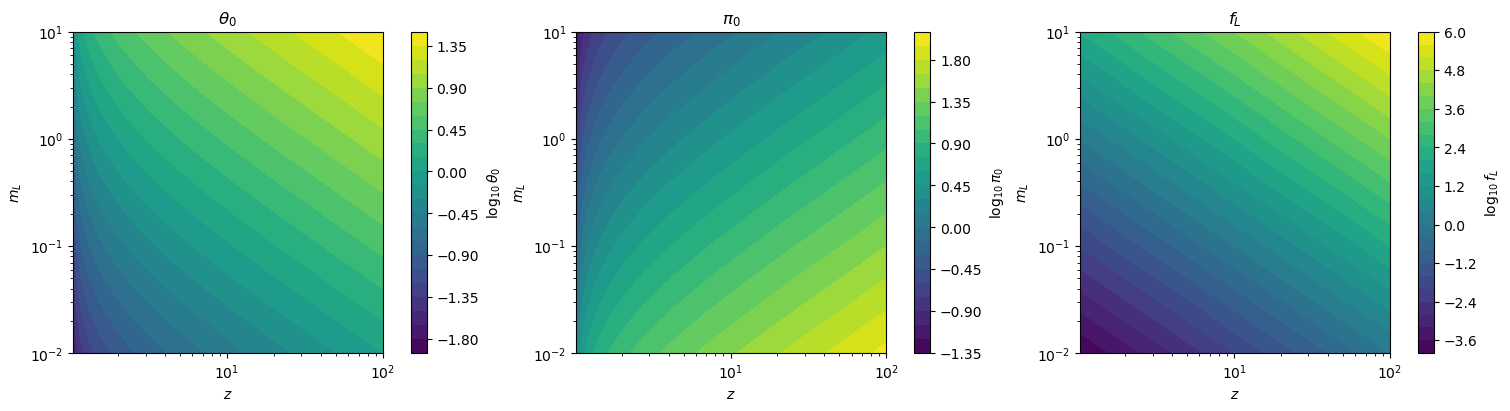

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters and constants
alpha = 2
C = 1.0

# Grid
mL = np.logspace(-2, 1, 300)   # 0.01 to 10 Msun
z = np.logspace(0.01, 2, 300)  # slightly above 1 to 100

Z, M = np.meshgrid(z, mL)

# Dimensionless observables
theta0 = np.sqrt(M * (Z - 1))
pi0 = np.sqrt((Z - 1) / M)
fL = C * M**alpha * Z**2

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

# theta_0
im1 = axes[0].contourf(
    Z, M, np.log10(theta0),
    levels=30
)
cbar1 = plt.colorbar(im1, ax=axes[0])
cbar1.set_label(r'$\log_{10}\theta_0$')

axes[0].set_title(r'$\theta_0$')
axes[0].set_xscale('log')
axes[0].set_yscale('log')

# pi_0
im2 = axes[1].contourf(
    Z, M, np.log10(pi0),
    levels=30
)
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label(r'$\log_{10}\pi_0$')

axes[1].set_title(r'$\pi_0$')
axes[1].set_xscale('log')
axes[1].set_yscale('log')

# f_L
im3 = axes[2].contourf(
    Z, M, np.log10(fL),
    levels=30
)
cbar3 = plt.colorbar(im3, ax=axes[2])
cbar3.set_label(r'$\log_{10}f_L$')

axes[2].set_title(r'$f_L$')
axes[2].set_xscale('log')
axes[2].set_yscale('log')

# Shared labels
for ax in axes:
    ax.set_ylabel(r'$m_L$')
    ax.set_xlabel(r'$z$')

plt.show()

## Interpretation of Plot

### $\theta_0$ Plot
For $z>>1$, $\theta_0 = \sqrt{m_L(z-1)} \rightarrow$ $\theta_0 \simeq \sqrt{m_Lz}$

$\log(\theta_0) = \frac{1}{2}\log(m_L) + \frac{1}{2}\log(z)$

Here, we can see that for large z, $m_L$ and $z$ change linearly, which is what we observe on the right side of the plot in the first panel. Additionally, we see that since both terms contribute positively, the direction that $\theta_0$ increases the fastest is up and to the right, which corresponds to a massive and nearby lens star, which is exactly the same behavior as the angular Einstein ring radius, $\theta_E$.

### $\pi_0$ Plot
For $z>>1$, $\pi_0 = \sqrt{\frac{z-1}{m_L}} \rightarrow$ $\pi_0 \simeq \sqrt{\frac{z}{m_L}}$

$\log(\pi_0) = \frac{1}{2}\log(z) - \frac{1}{2}\log(m_L)$

Here, we can see that for large z, $m_L$ and $z$ also change linearly, which we can observe on the right side of the second panel. We see that $z$ contributes positively and $m_L$ contributes negatively, so that the direction $\pi_E$ increases the fastest is down and to the right, corresponding to a low-mass and nearby star, which is the same behavior as the microlensing parallax, $\pi_E$. 

### $f_L$ Plot
$f_L = Cm_L^\alpha z^2$

For $\alpha=4$, $f_L = Cm_L^4 z^2$

$\log(f_L) = 4\log(m_L) + 2\log(z)$

We can see here that $m_L$ contributes to the dimensionless scaled lens flux twice as strong as $z$, which is evident in panel 3. $f_L$ is greatest for a massive and nearby star, which is the exact behavior that the actual lens flux, $F_L$, exhibits.

## Contour Map of of $\frac{\sigma_{m_L}}{m_L}$ and $\frac{\sigma_z}{z}$ in Various Combinations of $\theta_0$, $\pi_0$, and $f_L$
This figure serves to visually confirm certain special cases, in the error propagation of $m_L$ and $z$, such as when the uncertainty of one observable is much larger than another. Shown below is a plot featuring 6 subplots. The left 3 plots are the error in the dimensionless lens mass parameter, and the right 3 plots are the error in the dimensionless distance parameter using different combinations of observables.

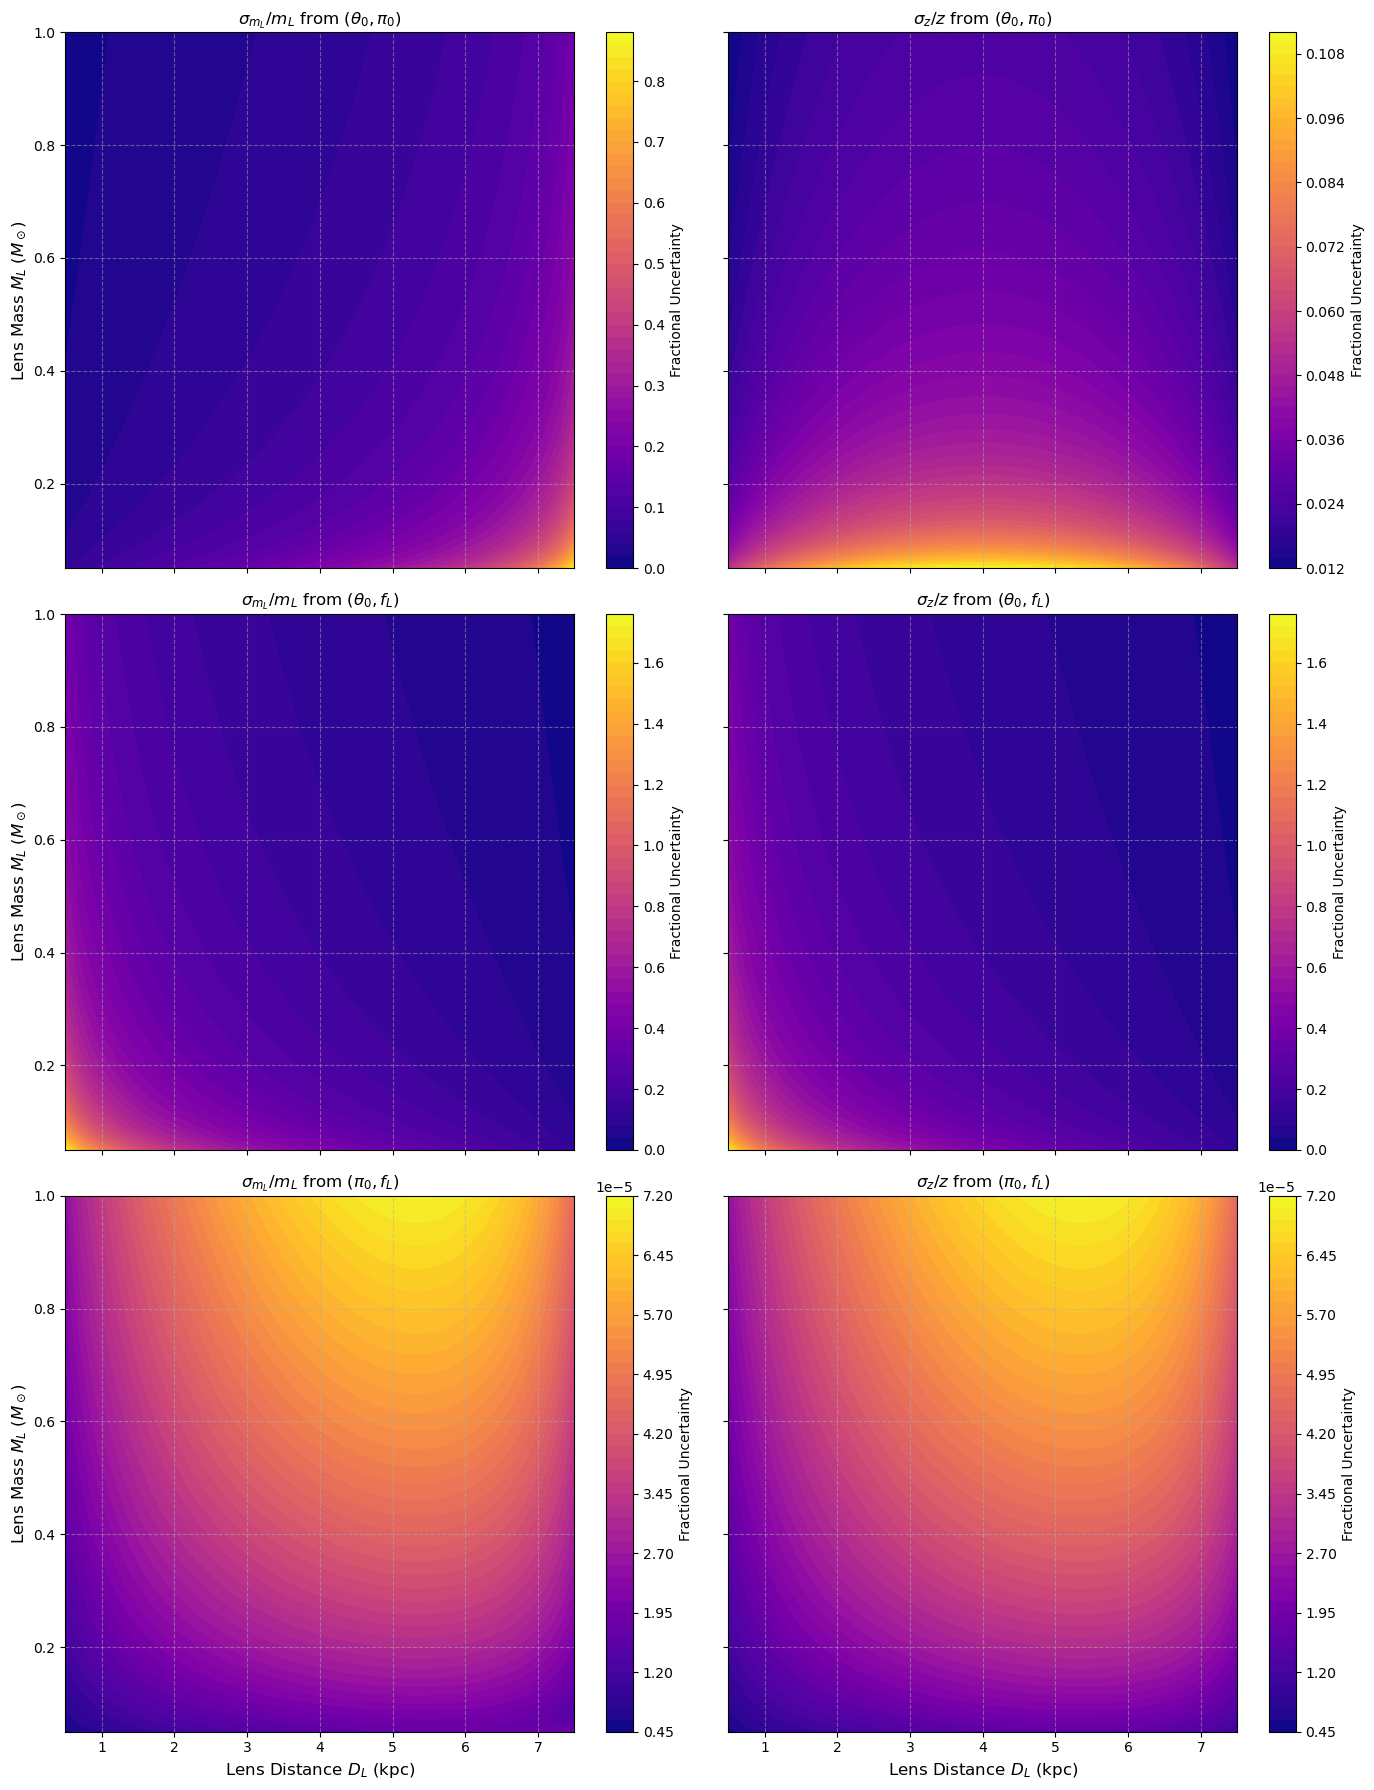

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters and constants
DS = 8.0          # Distance to source in kpc
C = 1.0           # Baseline flux scaling constant
alpha = 2.0       # Mass-luminosity index

# Define fractional uncertainties for the observables (10% each)
#err_theta = 0.10  # sigma_theta0 / theta0
#err_pi = 0.10     # sigma_pi0 / pi0
#err_f = 0.10      # sigma_fL / fL

# absolute measurement precisions
sigma_theta_abs = 0.05  
sigma_pi_abs    = 1e-4   
sigma_flux_abs  = 1e-7  

# Create physical grid: ML (Solar Masses) vs DL (kpc)
ml_grid = np.linspace(0.05, 1.0, 200)   # Mass grid
dl_grid = np.linspace(0.5, 7.5, 200)    # Distance grid (DL < DS)
ML, DL = np.meshgrid(ml_grid, dl_grid)

# Map Physical Grid to Dimensionless Observables 
z = DS / DL                               # Relative distance parameter
theta0 = np.sqrt(ML * (z - 1.0))          # Angular Einstein radius [cite: 15]
pi0 = np.sqrt((z - 1.0) / ML)             # Microlens parallax [cite: 17]
fL = C * (ML**alpha) * (z**2)             # Lens flux [cite: 21]

# convert to fractional uncertainties
err_theta = sigma_theta_abs/theta0
err_pi    = sigma_pi_abs/pi0
err_f  = sigma_flux_abs/fL

# Parameter B used in the (pi0, fL) combinations
B = np.sqrt(1.0 + 4.0 * (pi0**2) * np.sqrt(fL / C)) # [cite: 49]

# Create a base 2D array of ones with the same shape as our grid to force broadcasting
grid_ones = np.ones_like(ML)

# Compute the 6 Uncertainty Maps

# Pair 1: (theta0, pi0)
# Multiplied by grid_ones to ensure it becomes a 2D array instead of a 0D float
# sig_m_theta_pi = np.sqrt(err_theta**2 + err_pi**2) * grid_ones # [cite: 24]
sig_m_theta_pi = np.sqrt(err_theta**2 + err_pi**2)
sig_z_theta_pi = ((z - 1.0) / z) * np.sqrt(err_theta**2 + err_pi**2) # [cite: 25]

# Pair 2: (theta0, fL)
weight_f_theta = (ML + theta0**2) / (2.0 * ML)
weight_t_theta = (2.0 * theta0**2) / ML
sig_m_theta_f  = np.sqrt((weight_f_theta * err_f)**2 + (weight_t_theta * err_theta)**2) # [cite: 35]
sig_z_theta_f  = (z - 1.0) * np.sqrt(0.25 * (err_f**2) + 4.0 * (err_theta**2)) # [cite: 39]

# Pair 3: (pi0, fL)
sig_m_pi_f = np.sqrt(((B + 1.0) / (4.0 * B) * err_f)**2 + ((B - 1.0) / B * err_pi)**2) # [cite: 50]
sig_z_pi_f = ((2.0 * z - 2.0) / (2.0 * z - 1.0)) * np.sqrt((1.0 / 16.0) * (err_f**2) + err_pi**2) * grid_ones # [cite: 55]

# Plotting Configuration
fig, axes = plt.subplots(3, 2, figsize=(14, 18), sharex=True, sharey=True)
plots_data = [
    (sig_m_theta_pi, r"$\sigma_{m_L}/m_L$ from $(\theta_0, \pi_0)$"),
    (sig_z_theta_pi, r"$\sigma_z/z$ from $(\theta_0, \pi_0)$"),
    (sig_m_theta_f,  r"$\sigma_{m_L}/m_L$ from $(\theta_0, f_L)$"),
    (sig_z_theta_f,  r"$\sigma_z/z$ from $(\theta_0, f_L)$"),
    (sig_m_pi_f,     r"$\sigma_{m_L}/m_L$ from $(\pi_0, f_L)$"),
    (sig_z_pi_f,     r"$\sigma_z/z$ from $(\pi_0, f_L)$")
]

for ax, (data, title) in zip(axes.flatten(), plots_data):
    contour = ax.contourf(DL, ML, data, levels=50, cmap="plasma")
    cbar = fig.colorbar(contour, ax=ax)
    cbar.set_label("Fractional Uncertainty", fontsize=10)
    
    ax.set_title(title, fontsize=12)
    ax.grid(True, linestyle="--", alpha=0.5)

# Set global labels
for ax in axes[-1, :]:
    ax.set_xlabel(r"Lens Distance $D_L$ (kpc)", fontsize=12)
for ax in axes[:, 0]:
    ax.set_ylabel(r"Lens Mass $M_L$ ($M_\odot$)", fontsize=12)

plt.tight_layout()
plt.show()


## Plotting Fiducial Systems
This code also has the ability to plot 3 fiducial systems. 

### The Systems:
Each System has the source star at 8kpc.
1. Lens star is 0.2 $M_{\odot}$ and is 3 kpc away from us
2. Lens star is 0.8 $M_{\odot}$ and is 7 kpc away from us
3. Lens star is 0.5 $M_{\odot}$ and is 7 kpc away from us

### Plotting the Combinations
To plot the various combinations of observables, run the cell below. To interchange between the fiducial systems, change the first argument of **plot_mass_relation()** to:
1. 0p2Msun_3kpc
2. 0p5Msun_7kpc
3. 0p8Msun_7kpc


In [18]:
#from plotting import plot_mass_relation

#plot_mass_relation("0p2Msun_3kpc", method="thetaE_piE")
#plot_mass_relation("0p2Msun_3kpc", method="thetaE_FL")
#plot_mass_relation("0p2Msun_3kpc", method="piE_FL")
#plot_mass_relation("0p2Msun_3kpc", method="thetaE_piE_FL")
#plot_mass_relation("0p2Msun_3kpc", method="thetaE_piE_knownDL")
#plot_mass_relation("0p2Msun_3kpc", method="thetaE_knownDL")
#plot_mass_relation("0p2Msun_3kpc", method="piE_knownDL")



### Computing Derived Quantities for each System

To see the derived quantities you can get for each system, run the cell below. 
To change the system you are evaluating, change the name of the system inside **compute_derived_quantities()**.

In [19]:
#from computations import compute_derived_quantities

#derived_quantities = compute_derived_quantities('0p2Msun_3kpc')

#for key, value in derived_quantities.items():
#    print(f"{key}: {value}")

In [20]:
# you can directly call the functions from the mass_relations module if you want to derive specific quantities with
# parameters other than those define in the fiducial systems.

from mass_relations import M_FL, F_L

print(M_FL(0.2, 3))
print(F_L(0.2, 3))

1.2279920495357863
0.00035367765131532307
